In [1]:
import os
# import h5py
import cv2
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from tqdm import tqdm

import scienceplots
plt.style.use(['science', 'grid'])

from scipy.ndimage import gaussian_filter
from skimage import measure
import itertools
from sklearn.cluster import KMeans
from pathlib import Path

from TherMIFASOL.core.variables.GlobalVariables import (
    LAMBDA_NIR, T_SOLIDUS, T_LIQUIDUS, LINES_CRED, COLUMNS_CRED, FAC
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer,
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.core.data_processing.XIMEA_functions import (
    load_full_frame_nir, xiq_dl_to_flux_two_table, split_channel,
    xiq_bichromatic_temperature_field, xiq_emissivity_field, 
    apply_homographic_transformation
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/5 FirstEulerienMonitoring/"
)



# Calibration tables
#-------------------

#   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp550_WithNeutralDensity.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT40_deg1_NUC2.npy"
        )
    )


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/FirstEulerienMonitoring/")

## design of experiments
On the cell, only a single set of parameters currently enables stable processing. Therefore, in this experimental plan, we propose to make only minimal adjustments to the main process parameters (wire feed rate and laser power) and instead rely on alternative levers to induce variations in the melt pool behavior.

The investigated levers are:

* Unidirectional vs. bidirectional strategy
* With or without active cooling
* Camera field of view positioned near the melt pool or higher along the wall
* With or without laser power regulation via the Emaq-s camera
* Short vs. long delay time

| Strategy        | Active cooling | Position camera | Emaq-s | Delay | Folder name  |
|------------------|------------------------|-----------------|--------|---------------|-------|
| Unidirectional | yes                   | High            | No    | Short        |  RA  |
| Unidirectional | no                   | High            | No    | Short        |  SANS_GAZ  |
| Unidirectional | No                   | Low             | No    | Short        |  LOW_POS(_BIS) |
| Unidirectional | No                   | High            | Yes    | Short        |  EMAQS  |
| Bidirectional | No                   | High            | Yes    | Short        |  BIDIREC  |
| Unidirectional | No                   | High            | Yes    | Long        | TEMPOR_LONGUE |


In [3]:
configuration: str = 'RA'
layer_id: int = 32

pyro_pos_X, pyro_pos_Y = 593, 256
if configuration == 'LOW_POS_BIS' or configuration == 'LOW_POS':
    pyro_pos_X, pyro_pos_Y = 596, 101


## Camera

### Collect data

In [4]:
# Cannot cast ufunc 'add' output from dtype('float64') to dtype('uint16') with casting rule 'same_kind'
# The data type of the table may cause problems.

frame_every = 30
data_cordon= []

nb_img = len(os.listdir(f"{data_path}//{configuration}/cam_{configuration}_c{layer_id}/data"))
for im in np.arange(1, nb_img, frame_every):
    data_cordon.append(np.load(
        f"{data_path}/{configuration}/cam_{configuration}_c{layer_id}/data/im_{im}.npy"
        ))
    
    
data_cordon = np.asarray(data_cordon).astype(np.float64)
nb_img_sub = data_cordon.shape[0]

### Compute real FPS

In [5]:
time_acquisition = np.loadtxt(f"{data_path}/{configuration}/cam_{configuration}_c{layer_id}/time.txt")
dt = np.diff(time_acquisition)

fps_instant = 1.0 / dt

fps_mean = int(np.mean(fps_instant))
fps_std = np.std(fps_instant)

print(f"mean FPS : {fps_mean:.2f}")
print(f"Standard deviation of FPS : {fps_std:.2f}")

mean FPS : 599.00
Standard deviation of FPS : 31.90


### Animation - raw data

In [ ]:
name = "raw_animation"


x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)


# First set up the figure, the axis, and the plot element we want to animate
fig, ax = plt.subplots(1, 1, figsize=(10,6))

gray_scale_im = ax.imshow(data_cordon[0], cmap='gray', vmin=500, vmax=16000)

def animate_func(i):
    gray_scale_im.set_array(data_cordon[i])
    return gray_scale_im

anim = animation.FuncAnimation(fig, animate_func, frames=nb_img_sub, interval=1/fps_mean, repeat=False)

save_dir = os.path.join(saving_path, f"cam_{configuration}_c{layer_id}")
os.makedirs(save_dir, exist_ok=True)

anim.save(os.path.join(save_dir, f"{name}.gif"), writer='imagemagick', fps=fps_mean)
#anim.save('animation.mp4', writer='ffmpeg', fps=30, dpi=300)
#anim.save(f'couche_{cordon_connu}.gif', writer='PillowWriter', fps=fps)
plt.close(fig)


### Animation - thermal

In [ ]:
plt.close('all')
name = 'AAAA'
col_sol = 'green' 
col_liq = 'blue' 
col_pyro = 'red' 
eps = 0.73 
layer_height = 0.81 
radius_pyro = 0.4

fig, ax = plt.subplots(figsize=(10,6))

# Première image
im0 = dl_to_thermo(
    dl_raw=data_cordon[0],
    nuc_table=array_nuc,
    calibration_table=array_calibration,
    emissivity=eps
)
im0 = np.asarray(im0)

im = ax.imshow(im0, interpolation='nearest', vmin=500, vmax=1900,
               cmap=plt.cm.hot, extent=extent, origin='lower')

cb = fig.colorbar(im, orientation='vertical', fraction=.1)
cb.ax.set_ylabel("Temperature [K]")

# Pyro
circ = Circle((pyro_pos_X*FAC, pyro_pos_Y*FAC), radius_pyro, color=col_pyro,
              fill=False, linewidth=2, zorder=10)
ax.add_patch(circ)

# Labels et légende
ax.set_title(f'Layer {layer_id}')
ax.set_xlabel('[mm]')
ax.set_ylabel('[mm]')
ax.plot([], [], "o", color=col_sol, label='Solidus')
ax.plot([], [], "o", color=col_liq, label='Liquidus')
ax.plot([], [], "-", color='k', label=f"Bead height : {layer_height} mm")
ax.plot([], [], "-", color=col_pyro, label='Spot pyrometer')
ax.legend(loc='best', ncols=2, frameon=True)

# Axes
ax.set_xticks(np.array(xtick_pixels) * FAC)
ax.set_yticks(np.array(ytick_pixels) * FAC)
ax.set_xticklabels([f"{x:.0f}" for x in np.array(xtick_pixels) * FAC])
ax.set_yticklabels([f"{y:.1f}" for y in np.array(ytick_pixels) * FAC])
ax.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax.set_ylim((LINES_CRED - 1) * FAC, 0)
ax.grid(which='both')
fig.tight_layout()

# Scatter placeholders
sc_sol = ax.scatter([], [], s=2, c=col_sol)
sc_liq = ax.scatter([], [], s=2, c=col_liq)

def animate_func(i):
    new_im = dl_to_thermo(
        dl_raw=data_cordon[i],
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=eps
    )
    new_im = np.asarray(new_im)
    im.set_data(new_im)

    # Meshgrid des coordonnées
    ny, nx = new_im.shape
    x = np.linspace(extent[0], extent[1], nx)
    y = np.linspace(extent[2], extent[3], ny)
    X, Y = np.meshgrid(x, y)

    # Masques pour détecter zones proches des seuils
    mask_sol = (new_im > T_SOLIDUS-5) & (new_im < T_SOLIDUS+5)
    mask_liq = (new_im > T_LIQUIDUS-5) & (new_im < T_LIQUIDUS+5)

    # Extraire coordonnées
    sc_sol.set_offsets(np.c_[X[mask_sol], Y[mask_sol]])
    sc_liq.set_offsets(np.c_[X[mask_liq], Y[mask_liq]])

    return [im, sc_sol, sc_liq]

# interval en ms
interval_ms = max(1, int(1000.0 / fps_mean)) if fps_mean and fps_mean > 0 else 50

anim = animation.FuncAnimation(fig,
                               animate_func,
                               frames=nb_img_sub,
                               interval=interval_ms,
                               repeat=False,
                               blit=False)

# Save
save_dir = os.path.join(saving_path, f"cam_{configuration}_c{layer_id}")
os.makedirs(save_dir, exist_ok=True)
out_path = os.path.join(save_dir, f"{name}.gif")

anim.save(out_path, writer="imagemagick", fps=fps_mean)
plt.close(fig)

## Pyrometer

### Data collection

In [12]:
if configuration == 'TEMPOR_LONGUE':
    file_name = f"TEMPORLONGUE_unidirectionnel_emaqsNO_{layer_id}.csv"
else:
    file_name = f"{configuration}.csv"

data_path_pyrometer = os.path.join(
    data_path, 
    f"{configuration}/pyro_{configuration}/{file_name}"
    )

INFO = collect_data_pyrometer(csv_path=data_path_pyrometer)

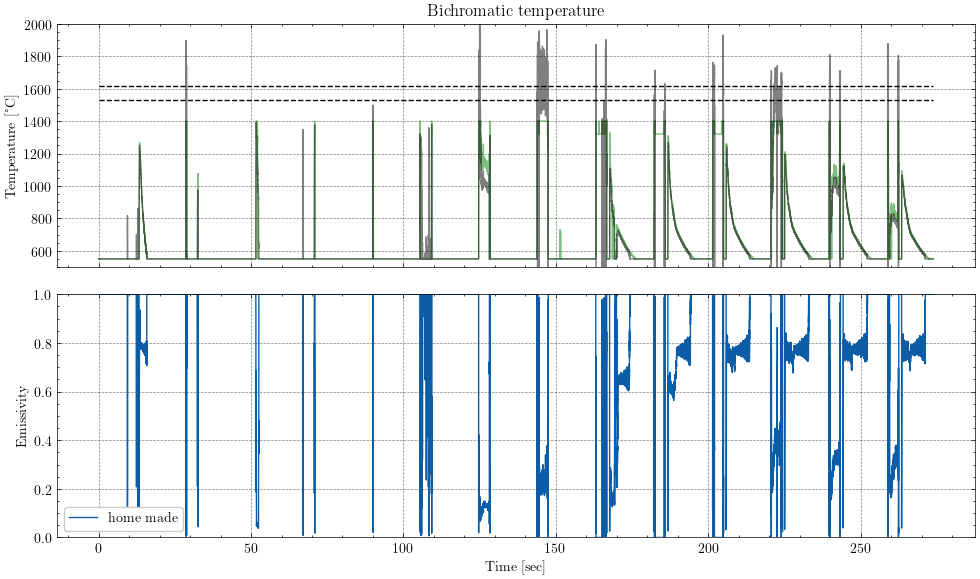

In [17]:
# DOUBLE GRAPH
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,6), sharex=True)

# Temperature
temps_ = INFO['array time']
ax1.plot(temps_, INFO['array temp2C'], label=f'home made', lw=1, c='g', alpha=0.5)
ax1.plot(temps_, INFO['array MAtemp2C'], label=f'constructor', lw=1, c='k', alpha=0.5)
ax1.plot([temps_[0], temps_[-1]], [T_LIQUIDUS]*2, '--',color="black", lw=1, alpha=1)
ax1.plot([temps_[0], temps_[-1]], [T_SOLIDUS]*2, '--',color="black", lw=1, alpha=1)
ax1.set_ylabel('Temperature [°C]')
ax1.set_ylim(0, 2000)
ax1.set_title('Bichromatic temperature')

# Emissivity
ax2.plot(temps_, INFO['array MAemissivity'], label=f'home made')
ax2.set_xlabel('Time [sec]')
ax2.set_ylim(0, 1)
ax2.set_ylabel('Emissivity')

fig.tight_layout()
ax1.set_ylim(ymin=500)
plt.legend()
# Afficher le graphique
plt.show()
